# Práctico 1 - Aplicación de NLP y embeddings


Para este práctico, se pide:

1. Elegir uno de los dos datasets a trabajar: reviews de IMDB ó sarcasmo (también válido: un dataset propio que consideres interesante).

1. Realizar una inspección del dataset que busque entender de qué se trata el dataset y el problema a resolver. La idea es inspeccionar no realizar un EDA completo, pueden valerse de herramientas que simplifiquen o realicen esta tarea.

1. Preprocesar los datos de texto teniendo en cuenta como baseline lo se vio anteriormente. Comparar tanto el uso de preprocesamientos típicos de NLP contra el uso de embeddings.

1. Entrenar distintos modelos y comparar sus diferencias.

1. Mostrar e Interpretar los resultados.


La notebook a presentar debe ser legible incluyendo
1. Introducción

1. Acompañar con comentarios que aporten a la interpretación de los resultados.

1. Una conclusión (breve pero no tan breve) con un resumen de lo trabajado y los resultados más representativos de acuerdo a su interpretación


Autor: Gonzalo Angaut

## Introducción

En el presente trabajo, utilizaremos un dataset de reviews de películas de IMDB para aplicar técnicas de procesamiento de lenguaje natural (NLP). Primero, realizaremos una inspección del dataset para comprender su estructura y el problema a resolver. Luego, aplicaremos distintos métodos de preprocesamiento de texto, incluyendo enfoques tradicionales (TF-IDF) y representaciones mediante embeddings. Finalmente, entrenaremos modelos de clasificación para comparar el desempeño de cada enfoque y analizar sus resultados.

Comenzamos instalando cosas necesarias e importando librerías a utilizar.

In [ ]:
!pip install --upgrade torch torchtext

In [ ]:
!pip install transformers

In [ ]:
!pip install gensim

In [ ]:
##### HACK
!pip uninstall numpy scipy gensim -y
!pip install gensim

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: gensim 4.3.3
Uninstalling gensim-4.3.3:
  Successfully uninstalled gensim-4.3.3
  Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.2 MB)
ERROR: pip's dependency resolver does not currently take into account all t

In [ ]:
import json
import requests

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


## Carga de datos

Cargamos los datos a utilizar:

Opción 1: [dataset de reviews de IMDB](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/code)

In [ ]:
# Remueve archivo anterior (si existe)
!rm -f imdb_dataset.csv

# Usa wget para descarga
file_id = "1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3"
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={file_id}" -O imdb_dataset.csv

# Carga el dataset
with open("imdb_dataset.csv", 'r') as file:
    df_imdb = pd.read_csv(file)
    print(f"Success! Dataset loaded with {len(df_imdb)} records.")


--2025-10-12 18:41:48--  https://docs.google.com/uc?export=download&id=1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3
Resolving docs.google.com (docs.google.com)... 74.125.24.100, 74.125.24.138, 74.125.24.113, ...
Connecting to docs.google.com (docs.google.com)|74.125.24.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3&export=download [following]
--2025-10-12 18:41:49--  https://drive.usercontent.google.com/download?id=1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.118.132, 2404:6800:4003:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.118.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66212309 (63M) [application/octet-stream]
Saving to: ‘imdb_dataset.csv’

imdb_dataset.csv    100%[===================>]  63.14M  57.7MB/s    i

Opción 2: [dataset de sarcasmo](https://www.kaggle.com/datasets/saurabhbagchi/sarcasm-detection-through-nlp?select=Sarcasm_Headlines_Dataset.json)

In [ ]:

# Remueve archivo anterior (si existe)
!rm -f sarcasm_dataset.json
# Use wget to download
file_id = "1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB"
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={file_id}" -O sarcasm_dataset.json

# Try to load
try:
    with open("sarcasm_dataset.json", 'r') as file:
        data = json.load(file)
    print(f"Success! Dataset loaded with {len(data)} records.")
except json.JSONDecodeError:
    print("Still having issues. Let's check the file...")
    !head -5 sarcasm_dataset.json

--2025-10-12 18:41:57--  https://docs.google.com/uc?export=download&id=1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB
Resolving docs.google.com (docs.google.com)... 74.125.24.100, 74.125.24.138, 74.125.24.113, ...
Connecting to docs.google.com (docs.google.com)|74.125.24.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB&export=download [following]
--2025-10-12 18:41:59--  https://drive.usercontent.google.com/download?id=1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.118.132, 2404:6800:4003:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.118.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5616830 (5.4M) [application/octet-stream]
Saving to: ‘sarcasm_dataset.json’

sarcasm_dataset.jso 100%[===================>]   5.36M  13.5MB/s 

In [ ]:
df_sarcasmo = pd.read_json("sarcasm_dataset.json", lines=True)

## Selección del dataset

Para este práctico, se eligió trabajar con el dataset de reviews de IMDB (Internet Movie Database, en español: Base de Datos de Películas en Internet).
El dataset contiene 50.000 críticas de películas y está etiquetado para un problema de clasificación binaria: cada crítica se marca como positiva o negativa.

El objetivo del trabajo es analizar cómo diferentes representaciones de texto (TF–IDF, embeddings de Word2Vecm FastText y BERT) afectan el rendimiento de modelos de clasificación sobre estas críticas.

Se realizará primero una inspección del dataset para entender su estructura y distribución, luego se aplicará un preprocesamiento básico de NLP, y finalmente se compararán distintos enfoques de representación y clasificación para interpretar sus resultados.

Comencemos viendo algunas críticas:

In [ ]:
df = df_imdb
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Podemos ver cómo aparece cada crítica en la columna `review`, mientras que en `sentiment` se indica si la crítica es positiva o negativa.

## Pequeña inspección de los datos

Comenzamos haciendo una inspección y exploración de los datos.

Veamos una descripción e información básica del dataset:

In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


Vemos que todos los datos son de tipo `object` y no hay valores faltantes.

Elegimos una semilla para reproducibilidad.

In [ ]:
seed=15

Separamos las críticas de la variable objetivo y dividimos el conjunto en datos de entrenamiento, validación y testeo.

In [ ]:
X = df['review'].values
y = df['sentiment'].values

# Tomamos un 70% de los datos de entrenamiento, 15% de validación y 15% de testeo
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

print(f'Cantidad de datos en train: {X_train.shape[0]}')
print(f'Cantidad de datos en validación: {X_val.shape[0]}')
print(f'Cantidad de datos en test: {X_test.shape[0]}')

Cantidad de datos en train: 35000
Cantidad de datos en validación: 7500
Cantidad de datos en test: 7500


Veamos si las clases están balanceadas en cada uno de los conjuntos.

In [ ]:
# Convertimos a Series para usar value_counts
y_train_s = pd.Series(y_train)
y_val_s   = pd.Series(y_val)
y_test_s  = pd.Series(y_test)

print("Distribución de clases en entrenamiento:\n", y_train_s.value_counts(normalize=True))
print("\nDistribución de clases en validación:\n", y_val_s.value_counts(normalize=True))
print("\nDistribución de clases en test:\n", y_test_s.value_counts(normalize=True))


Distribución de clases en entrenamiento:
 negative    0.500343
positive    0.499657
Name: proportion, dtype: float64

Distribución de clases en validación:
 positive    0.504267
negative    0.495733
Name: proportion, dtype: float64

Distribución de clases en test:
 negative    0.502667
positive    0.497333
Name: proportion, dtype: float64


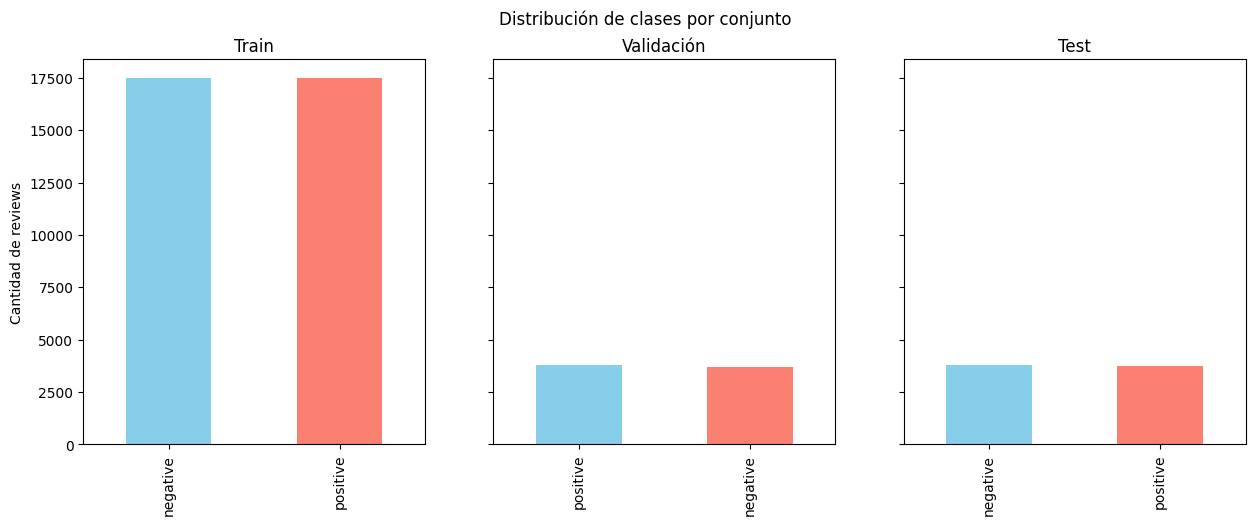

In [ ]:
# Creamos gráficos de barra
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

# Train
y_train_s.value_counts().plot(kind='bar', ax=axes[0], color=['skyblue','salmon'], title='Train')
axes[0].set_ylabel('Cantidad de reviews')

# Validación
y_val_s.value_counts().plot(kind='bar', ax=axes[1], color=['skyblue','salmon'], title='Validación')

# Test
y_test_s.value_counts().plot(kind='bar', ax=axes[2], color=['skyblue','salmon'], title='Test')

plt.suptitle('Distribución de clases por conjunto')
plt.show()

Nótese que en los 3 casos la cantidad de críticas negativas y positivas es del 50% del total, lo que indica que un gran balanceo de clases.

También podemos ver el tamaño de las críticas en el conjunto de entrenamiento.

Longitud mínima: 8
Longitud máxima: 2125
Longitud promedio: 231.72817142857141


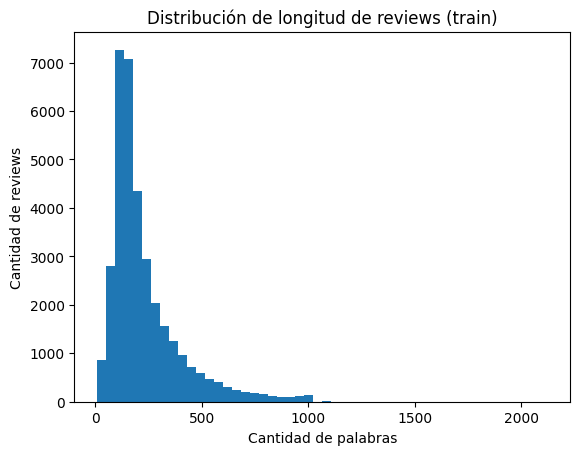

In [ ]:
text_lengths = [len(text.split()) for text in X_train]
print("Longitud mínima:", min(text_lengths))
print("Longitud máxima:", max(text_lengths))
print("Longitud promedio:", sum(text_lengths)/len(text_lengths))

# Histograma
plt.hist(text_lengths, bins=50)
plt.title("Distribución de longitud de reviews (train)")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Cantidad de reviews")
plt.show()

Podemos ver que la distribución es asimétrica positiva (right skewed) con cola hacia la derecha. Esto significa que la mayoría de las reviews son relativamente cortas o medianas pero hay algunas muy largas.

Por último, veamos algun ejemplo representativo de tanto de una review positiva como negativa.

In [ ]:
# Reviews positivas
print("Ejemplo positivo:\n", X_train[y_train=="positive"][0])
# Reviews negativas
print("\nEjemplo negativo:\n", X_train[y_train=="negative"][0])

Ejemplo positivo:
 The sequel is exactly what you will expect it to be. And it is good enough that everyone who would have wanted to watch this should leave it happy.<br /><br />This is not a movie that will win an Academy award. But it does take what made the Jackass TV show and original movie a success, and it turns it up a notch. It is funnier, more brutal, and more disgusting than the original. And I loved every minute of it.<br /><br />The original had a few notorious stunts, and there is at least one stunt that this movie will be remembered for. You will wince, cringe, look away, and laugh very, very hard.<br /><br />In any event, you probably do not need to read this review, or any others, to know if you will like this movie, unless you have never heard of Jackass.

Ejemplo negativo:
 I made the mistake of buying this since I collect comic book inspired movies. Even at 6$ it was too expensive. I thought there might be some campy fun in it, a "so bad" it becomes good vibe perhaps

## Procesamiento de texto y modelado




Una vez ya explorado el modelo, podemos hacer un procesamiento del texto para posterior modelado.

## TF-IDF

Empezamos con un preprocesamiento típico de NLP con TF-IDF. La idea detrás es que cuanto más común es una palabra en todos los documentos, menor es su importancia para el documento actual.

Vamos a hacer una limpieza básica, eliminando URLs, puntuación y normalizando espacios para luego hacer tokenización, eliminar stopwords y, finalmente, lematización.

In [ ]:
# Importamos librerías necesarias
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Descargamos recursos necesarios de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Descargamos las stop words en ingles
nltk.download("stopwords") # Descargamos las stop words
stop_words = set(stopwords.words('english'))
# Definimos el lemmatizer
lemmatizer = WordNetLemmatizer()

# Definimos la función de preprocesamiento
def preprocess(text):
    # Limpieza básica
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)  # quitar URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)      # quitar puntuación
    text = re.sub(r"\s+", " ", text).strip()      # normalizar espacios

    # Tokenización
    tokens = word_tokenize(text)

    # Stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Lematización
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Aplicamos la función al dataset.

In [ ]:
X_train_tok = [preprocess(doc) for doc in X_train]
X_val_tok   = [preprocess(doc) for doc in X_val]
X_test_tok  = [preprocess(doc) for doc in X_test]

Reconvertimos a strings para usar TF-IDF:

In [ ]:
X_train_clean = [" ".join(tokens) for tokens in X_train_tok]
X_val_clean   = [" ".join(tokens) for tokens in X_val_tok]
X_test_clean  = [" ".join(tokens) for tokens in X_test_tok]

Podemos comparar una review antes del preprocesamiento con una después.

Antes:

In [ ]:
X_train[1]

"This is a pretty well known one so i won't get too deep into it. The basic story is about two teens who find out about a slimy alien blob of goo that arrives to earth via meteor. Human contact with this slime ball burns through flesh like acid. It also absorbs human bodies making it grow bigger. Nobody believes the teens (Steeve McQueen and his girlfriend) and when they finally do it seems that the blob can't be stopped. It's really well done for it's age and unlike a lot of other 50's flicks the pace is pretty fast. The story is very unique making it and a must see for any fan of old sci-fi and monster movies. If you can dig the gooey gore of 80s horror be sure to check out the remake from '88 as well."

Después:

In [ ]:
X_train_tok[1]

['pretty',
 'well',
 'known',
 'one',
 'get',
 'deep',
 'basic',
 'story',
 'two',
 'teen',
 'find',
 'slimy',
 'alien',
 'blob',
 'goo',
 'arrives',
 'earth',
 'via',
 'meteor',
 'human',
 'contact',
 'slime',
 'ball',
 'burn',
 'flesh',
 'like',
 'acid',
 'also',
 'absorbs',
 'human',
 'body',
 'making',
 'grow',
 'bigger',
 'nobody',
 'belief',
 'teen',
 'steeve',
 'mcqueen',
 'girlfriend',
 'finally',
 'seems',
 'blob',
 'stopped',
 'really',
 'well',
 'done',
 'age',
 'unlike',
 'lot',
 '50',
 'flick',
 'pace',
 'pretty',
 'fast',
 'story',
 'unique',
 'making',
 'must',
 'see',
 'fan',
 'old',
 'sci',
 'fi',
 'monster',
 'movie',
 'dig',
 'gooey',
 'gore',
 '80',
 'horror',
 'sure',
 'check',
 'remake',
 '88',
 'well']

In [ ]:
X_train_clean[1]

'pretty well known one get deep basic story two teen find slimy alien blob goo arrives earth via meteor human contact slime ball burn flesh like acid also absorbs human body making grow bigger nobody belief teen steeve mcqueen girlfriend finally seems blob stopped really well done age unlike lot 50 flick pace pretty fast story unique making must see fan old sci fi monster movie dig gooey gore 80 horror sure check remake 88 well'

Una vez hecha la limpieza, creamos el vectorizador con TD-IDF:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Creamos el vectorizador
tfidf = TfidfVectorizer()
#tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Lo entrenamos solo con el conjunto de entrenamiento
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf   = tfidf.transform(X_val_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

Vemos que ahora cada crítica queda como una matriz esparsa comprimida:

In [ ]:
X_train_tfidf[1]

<1x78625 sparse matrix of type '<class 'numpy.float64'>'
	with 68 stored elements in Compressed Sparse Row format>

Podemos visualizar qué términos son más relevantes para una review particular según el modelo TF-IDF.

In [ ]:
df = pd.DataFrame(X_train_tfidf[0].T.todense(),
    	index=tfidf.get_feature_names_out(), columns=["TF-IDF"])
df = df.sort_values('TF-IDF', ascending=False)
df.shape

df.sort_values(by=['TF-IDF'], ascending=False).head()

,TF-IDF
jackass,0.391119
stunt,0.303784
original,0.273472
br,0.246813
wince,0.215381


Ahora definimos el modelo de clasificación. Vamos a codificar la salida ya que lo necesitamos para posterior uso del XGBoost.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inicializamos el codificador
label_encoder = LabelEncoder()

# Ajustamos y transformamos el conjunto de entrenamiento
y_train_num = label_encoder.fit_transform(y_train)

# Transformamos los conjuntos de validación y prueba
y_val_num = label_encoder.transform(y_val)
y_test_num = label_encoder.transform(y_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [ ]:
def train_and_evaluate_model(X_train_model, X_val_model):

    clfs_list =  [LogisticRegression(max_iter=1000, random_state=seed),
        LinearSVC(max_iter=2000, random_state=seed),
        XGBClassifier(random_state=seed, use_label_encoder=False, eval_metric='logloss'),
        MLPClassifier(max_iter=500, random_state=seed, early_stopping=True)]

    names = ['Regresión Logística', 'SVM Lineal', 'XGBoost', 'MLP']

    resultados = {'Clasificador': [], 'Accuracy': [], 'F1-Score': []}

    modelos_entrenados = {}

    for clf, name in zip(clfs_list, names):
        print(f"Entrenando: {name}...")

        # Entrenamos
        clf.fit(X_train_model, y_train_num)

        modelos_entrenados[name] = clf

        # Evaluamos en validación
        y_pred_val = clf.predict(X_val_model)

        acc = accuracy_score(y_val_num, y_pred_val)
        f1 = f1_score(y_val_num, y_pred_val)

        print(f"--> {name} - Acc: {acc:.4f} | F1: {f1:.4f}\n")

        resultados['Clasificador'].append(name)
        resultados['Accuracy'].append(acc)
        resultados['F1-Score'].append(f1)

    return resultados, modelos_entrenados

In [ ]:
resultados_tfidf, modelos_entrenados_tfidf = train_and_evaluate_model(X_train_tfidf, X_val_tfidf)

Entrenando: Regresión Logística...
--> Regresión Logística - Acc: 0.8887 | F1: 0.8912

Entrenando: SVM Lineal...
--> SVM Lineal - Acc: 0.8928 | F1: 0.8947

Entrenando: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:44:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--> XGBoost - Acc: 0.8544 | F1: 0.8586

Entrenando: MLP...
--> MLP - Acc: 0.8995 | F1: 0.9002



Por lo tanto, a partir de las métricas, elegimos como modelo ganador a MLP. Veamos como funciona en el conjunto de testeo:

In [ ]:
clf_ganador_tfidf = modelos_entrenados_tfidf['MLP']

# Predecir y evaluamos en el conjunto de testeo
y_pred_test_tfidf = clf_ganador_tfidf.predict(X_test_tfidf)

# Calculamos las métricas
acc_test_tfidf = accuracy_score(y_test_num, y_pred_test_tfidf)
f1_test_tfidf = f1_score(y_test_num, y_pred_test_tfidf)

print(f"Accuracy en test: {acc_test_tfidf:.4f}")
print(f"F1-Score en test: {f1_test_tfidf:.4f}")

Accuracy en test: 0.8989
F1-Score en test: 0.8974


Con el modelo tradicional basado en TF-IDF, logramos un rendimiento alto (≈89 %) y estable entre validación y test.
Esto muestra que la representación TF-IDF es efectiva para capturar las palabras clave más relevantes del sentimiento en las reseñas, aunque no considera la estructura semántica del lenguaje, algo que sí hacen los embeddings.

Podemos ver cuales son las palabras más asociadas a cada categoría de las reviews en regresión logística:

In [ ]:
clf_regresion=modelos_entrenados_tfidf['Regresión Logística']

# Obtenemos los pesos del modelo (coeficientes)
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf_regresion.coef_[0]

# Ordenamos las palabras por su peso
top_positive = np.argsort(coefs)[-20:]
top_negative = np.argsort(coefs)[:20]

print("Palabras más asociadas a reviews POSITIVAS:")
print(feature_names[top_positive])

print("Palabras más asociadas a reviews NEGATIVAS:")
print(feature_names[top_negative])

Palabras más asociadas a reviews POSITIVAS:
['beautiful' 'enjoyable' 'highly' 'definitely' 'love' 'hilarious' 'fun'
 'superb' 'well' 'brilliant' 'today' 'enjoyed' 'loved' 'wonderful'
 'amazing' 'favorite' 'perfect' 'best' 'excellent' 'great']
Palabras más asociadas a reviews NEGATIVAS:
['worst' 'bad' 'waste' 'awful' 'boring' 'poor' 'terrible' 'nothing'
 'worse' 'horrible' 'dull' 'poorly' 'unfortunately' 'stupid' 'fails'
 'annoying' 'disappointment' 'lame' 'minute' 'supposed']


## Word2Vec

Ahora utilicemos embeddings. Word2Vec es el primer modelo de embeddings distribucionales, es uno de los enfoques más conocidos y se basa en la idea de que el significado de una palabra se define por su contexto.

Descargamos el Word2Vec preentrenado:

In [ ]:
import gensim.downloader as api
from gensim import models
from gensim.models import KeyedVectors
from gensim.models import Word2Vec

path = api.load("word2vec-google-news-300", return_path=True)
print("Modelo Word2Vec descargado en:", path)

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Modelo Word2Vec descargado en: /root/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz


In [ ]:
w2v = models.KeyedVectors.load_word2vec_format('/root/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz', binary=True)

Definimos una función para vectorizar las reviews, tomando el promedio sobre todos los tokens.

In [ ]:
def vectorize_review(tokens, model):
    vectors = [model[word] for word in tokens if word in model]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    else:
        return np.mean(vectors, axis=0)

Y ahora vectorizamos todas las reviews:

In [ ]:
X_train_vec_w2v = np.array([vectorize_review(tokens, w2v) for tokens in X_train_tok])
X_val_vec_w2v   = np.array([vectorize_review(tokens, w2v) for tokens in X_val_tok])
X_test_vec_w2v  = np.array([vectorize_review(tokens, w2v) for tokens in X_test_tok])

Veamos las dimensiones:

In [ ]:
print("Dimensiones de X_train_vec:", X_train_vec_w2v.shape)

Dimensiones de X_train_vec: (35000, 300)


Veamos un ejemplo de lo hecho, viendo primero el texto original, los tokens obtenidos y luego el vector promedio de la review.

In [ ]:
# Tomamos la primera review del entrenamiento
print("Texto original:")
print(X_train[0])

print("\nTokens preprocesados:")
print(X_train_tok[0])

print("\nVector promedio (embedding) de la review:")
print(X_train_vec_w2v[0])
print("Dimensiones del vector:", X_train_vec_w2v[0].shape)

Texto original:
The sequel is exactly what you will expect it to be. And it is good enough that everyone who would have wanted to watch this should leave it happy.<br /><br />This is not a movie that will win an Academy award. But it does take what made the Jackass TV show and original movie a success, and it turns it up a notch. It is funnier, more brutal, and more disgusting than the original. And I loved every minute of it.<br /><br />The original had a few notorious stunts, and there is at least one stunt that this movie will be remembered for. You will wince, cringe, look away, and laugh very, very hard.<br /><br />In any event, you probably do not need to read this review, or any others, to know if you will like this movie, unless you have never heard of Jackass.

Tokens preprocesados:
['sequel', 'exactly', 'expect', 'good', 'enough', 'everyone', 'would', 'wanted', 'watch', 'leave', 'happy', 'br', 'br', 'movie', 'win', 'academy', 'award', 'take', 'made', 'jackass', 'tv', 'show', 

Finalmente, hacemos la clasificación.

In [ ]:
resultados_w2v, modelos_entrenados_w2v = train_and_evaluate_model(X_train_vec_w2v, X_val_vec_w2v)

Entrenando: Regresión Logística...
--> Regresión Logística - Acc: 0.8491 | F1: 0.8512

Entrenando: SVM Lineal...
--> SVM Lineal - Acc: 0.8532 | F1: 0.8554

Entrenando: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:03:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--> XGBoost - Acc: 0.8348 | F1: 0.8371

Entrenando: MLP...
--> MLP - Acc: 0.8565 | F1: 0.8566



Por lo tanto, a partir de las métricas, elegimos como modelo ganador a MLP. Veamos como funciona en el conjunto de testeo:

In [ ]:
clf_ganador_w2v = modelos_entrenados_w2v['MLP']

# Predecir y evaluamos en el conjunto de testeo
y_pred_test_w2v = clf_ganador_w2v.predict(X_test_vec_w2v)

# Calculamos las métricas
acc_test_w2v = accuracy_score(y_test_num, y_pred_test_w2v)
f1_test_w2v = f1_score(y_test_num, y_pred_test_w2v)

print(f"Accuracy en test: {acc_test_w2v:.4f}")
print(f"F1-Score en test: {f1_test_w2v:.4f}")

Accuracy en test: 0.8580
F1-Score en test: 0.8562


El modelo con Word2Vec promedio obtiene un rendimiento ligeramente inferior a TF-IDF (≈0.85 vs 0.89), lo cual puede tener que ver con la pérdida de información ya que estamos promediando embeddings.

Sin embargo, Word2Vec permite representar semánticamente palabras y compararlas entre reviews, lo que es útil para tareas más complejas y modelos que capturen contexto.

## FastText

Ahora usaremos FastText, que se basa en Word2Vec pero es más robusto, ya que descompone las palabras en subpalabras o n-gramas de caracteres.

Comenzamos cargando el modelo preentrenado.

In [ ]:
from gensim.models import FastText

In [ ]:
try:
    ft_model = api.load("fasttext-wiki-mini")
except ValueError:
    print("fasttext-wiki-mini not found. Trying a larger model...")
    ft_model = api.load("fasttext-wiki-news-subwords-300")

print("Modelo FastText cargado.")
print(f"Vocabulario: {len(ft_model.index_to_key)} palabras")

fasttext-wiki-mini not found. Trying a larger model...
[==================================================] 100.0% 958.5/958.4MB downloaded
Modelo FastText cargado.
Vocabulario: 999999 palabras


Para vectorizar con el promedio de embeddings podemos usar la función definida previamente de `vectorize_review(tokens, model)`.

In [ ]:
X_train_vec_ft = np.array([vectorize_review(tokens, ft_model) for tokens in X_train_tok])
X_val_vec_ft   = np.array([vectorize_review(tokens, ft_model) for tokens in X_val_tok])
X_test_vec_ft  = np.array([vectorize_review(tokens, ft_model) for tokens in X_test_tok])

Veamos las dimensiones ahora:

In [ ]:
print("Dimensiones de X_train_vec_ft:", X_train_vec_ft.shape)

Dimensiones de X_train_vec_ft: (35000, 300)


Por ultimo, realizamos la clasificación:

In [ ]:
resultados_ft, modelos_entrenados_ft = train_and_evaluate_model(X_train_vec_ft, X_val_vec_ft)

Entrenando: Regresión Logística...
--> Regresión Logística - Acc: 0.8164 | F1: 0.8192

Entrenando: SVM Lineal...
--> SVM Lineal - Acc: 0.8385 | F1: 0.8410

Entrenando: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:09:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--> XGBoost - Acc: 0.8232 | F1: 0.8258

Entrenando: MLP...
--> MLP - Acc: 0.8429 | F1: 0.8444



Por lo tanto, a partir de las métricas, elegimos como modelo ganador a MLP. Veamos como funciona en el conjunto de testeo:

In [ ]:
clf_ganador_ft = modelos_entrenados_ft['MLP']

# Predecir y evaluamos en el conjunto de testeo
y_pred_test_ft = clf_ganador_ft.predict(X_test_vec_ft)

# Calculamos las métricas
acc_test_ft = accuracy_score(y_test_num, y_pred_test_ft)
f1_test_ft = f1_score(y_test_num, y_pred_test_ft)

print(f"Accuracy en test: {acc_test_ft:.4f}")
print(f"F1-Score en test: {f1_test_ft:.4f}")

Accuracy en test: 0.8475
F1-Score en test: 0.8466


Al igual que antes, los resultados no mejoran los de TF-IDF, aunque están cerca. El tiempo en ejecución sí mejora notablemente, por lo tanto, lo que ganamos en eficiencia (tiempo, recursos), podemos reinvertirlo en mejorar otras partes del sistema.

## BERT

En este enfoque, la principal innovación es que comprende el contexto de las palabras examinando las palabras que la preceden y las que la siguen a la vez.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

# Modelo BERT base
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

En este caso, no podemos hacer el mismo preprocesamiento de antes ya que BERT es contextual, por lo que hay que tratar de distinta forma a los datos. Además, tiene su propio tokenizador.

In [ ]:
def get_bert_embeddings(texts, tokenizer, model, batch_size=32, device='cuda' if torch.cuda.is_available() else 'cpu'):
    # Usamos gpu si está disponible
    model = model.to(device)
    print("Estamos usando: ", device)
    # Modo evaluación
    model.eval()

    # Guardamos los embeddings
    embeddings = []
    with torch.no_grad():
        # Procesamos por lotes
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            # Tokenización
            inputs = tokenizer(batch, padding=True, truncation=True, return_tensors='pt', max_length=128).to(device)
            # Ejecutamos BERT
            outputs = model(**inputs)
            # Tomamos el promedio por token
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_emb)
    return np.vstack(embeddings)

Generamos los embeddings:

In [ ]:
X_train_bert = get_bert_embeddings(X_train.tolist(), tokenizer, model)
X_val_bert   = get_bert_embeddings(X_val.tolist(), tokenizer, model)
X_test_bert  = get_bert_embeddings(X_test.tolist(), tokenizer, model)

print("Dimensiones de embeddings BERT:")
print(X_train_bert.shape, X_val_bert.shape, X_test_bert.shape)

Estamos usando:  cuda
Estamos usando:  cuda
Estamos usando:  cuda
Dimensiones de embeddings BERT:
(35000, 768) (7500, 768) (7500, 768)


Entrenamos el modelo de clasificación:

In [ ]:
resultados_bert, modelos_entrenados_bert = train_and_evaluate_model(X_train_bert, X_val_bert)

Entrenando: Regresión Logística...
--> Regresión Logística - Acc: 0.8293 | F1: 0.8298

Entrenando: SVM Lineal...
--> SVM Lineal - Acc: 0.8288 | F1: 0.8288

Entrenando: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:15:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--> XGBoost - Acc: 0.7973 | F1: 0.7983

Entrenando: MLP...
--> MLP - Acc: 0.8300 | F1: 0.8280



Y evaluamos en el conjunto de testeo:

In [ ]:
clf_ganador_bert = modelos_entrenados_bert['MLP']

# Predecir y evaluamos en el conjunto de testeo
y_pred_test_bert = clf_ganador_bert.predict(X_test_bert)

# Calculamos las métricas
acc_test_bert = accuracy_score(y_test_num, y_pred_test_bert)
f1_test_bert = f1_score(y_test_num, y_pred_test_bert)

print(f"Accuracy en test: {acc_test_bert:.4f}")
print(f"F1-Score en test: {f1_test_bert:.4f}")

Accuracy en test: 0.8340
F1-Score en test: 0.8295


## Comparación de los modelos

Ahora veamos como funcionó la clasificación utilizando los distintos enfoques de representación:

In [ ]:
# Creamos DataFrame para comparar los resultados de test
resultados_test_comparados = pd.DataFrame({
    'Enfoque de Representación': ['TF-IDF', 'Word2Vec', 'FastText', 'BERT'],
    'Accuracy en Test': [acc_test_tfidf, acc_test_w2v, acc_test_ft, acc_test_bert],
    'F1-Score en Test': [f1_test_tfidf, f1_test_w2v, f1_test_ft, f1_test_bert]
})

display(resultados_test_comparados)

,Enfoque de Representación,Accuracy en Test,F1-Score en Test
0,TF-IDF,0.898933,0.897401
1,Word2Vec,0.858000,0.856178
2,FastText,0.847467,0.846649
3,BERT,0.834000,0.829475


Podemos ver que TF-IDF es el que mejor clasifica, seguido de Word2Vec, luego FastText y por último BERT, aunque todos por encima del 80%.

## Conclusiones

En conclusión, a pesar de lo que uno podría pensar a priori, TF-IDF es el enfoque que mejor funciona para la clasificación en este dataset. Esto indica que el dataset IMDB reviews es muy informativo a nivel de palabras clave: términos como excellent, boring, funny o awful ya permiten distinguir claramente la clase.

Los embeddings (Word2Vec, FastText y BERT) capturan relaciones semánticas y contexto, por lo que se consideran enfoques más robustos que TF-IDF en general. Sin embargo, al promediar los embeddings por review, se pierde información importante para este problema específico.

Word2Vec y FastText generan embeddings estáticos; la media de tokens no conserva toda la información discriminativa, lo que explica su menor desempeño.

BERT proporciona embeddings contextuales, pero sin fine-tuning y usando mean pooling, no logra superar a TF-IDF en este caso.

Por lo tanto, un enfoque tradicional como TF-IDF sigue siendo sorprendentemente competitivo cuando las palabras clave son suficientes para separar clases, a pesar de que los embeddings más complejos capturen semántica más rica.